# Análisis de Series Temporales - Datos de Diabetes

Este notebook utiliza **statsmodels** para analizar series temporales de pacientes diabéticos. Los datos provienen de 70 pacientes con registros de:
- Niveles de glucosa en sangre
- Dosis de insulina
- Hábitos de estilo de vida

El objetivo es identificar patrones temporales, tendencias y realizar pronósticos.

## 1. Importación de Librerías

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Librerías de statsmodels para series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print("Librerías importadas correctamente")
print(f"Statsmodels versión: {__import__('statsmodels').__version__}")

Librerías importadas correctamente
Statsmodels versión: 0.14.5


## 2. Carga de Datos

Los datos están en 70 archivos individuales (data-01 hasta data-70+), cada uno representando un paciente diferente.

**Formato de los datos:**
- Columna 1: Fecha (MM-DD-YYYY)
- Columna 2: Hora (HH:MM)
- Columna 3: Código de medición
- Columna 4: Valor

**Códigos principales:**
- **33**: Insulina Regular
- **34**: Insulina NPH  
- **48**: Glucosa pre-sueño
- **57**: Insulina Ultra Lente
- **58**: Glucosa pre-desayuno
- **59**: Glucosa post-desayuno
- **60**: Glucosa pre-almuerzo
- **61**: Glucosa post-almuerzo
- **62**: Glucosa pre-cena
- **63**: Glucosa post-cena
- **64**: Glucosa post-ejercicio
- **65**: Hipoglucemia (síntomas)
- **66**: Enfermedad típica
- **67**: Pre-menstruación
- **68**: Enfermedad menor
- **69**: Estrés mayor
- **70**: Estrés convencional
- **71**: Ciclo menstrual
- **72**: Actividad física

In [23]:
# Ruta a los datos
data_dir = './diabetes_records/Diabetes-Data/'

# Función para cargar un archivo individual
def load_patient_data(file_path):
    """Carga datos de un paciente desde archivo"""
    df = pd.read_csv(
        file_path,
        sep='\t',
        header=None,
        names=['date', 'time', 'code', 'value']
    )

    # Combinar fecha y hora
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%m-%d-%Y %H:%M')

    # Extraer número de paciente
    patient_id = os.path.basename(file_path).split('-')[-1]
    df['patient_id'] = patient_id

    return df

# Cargar todos los archivos
all_files = sorted(glob.glob(os.path.join(data_dir, 'data-*')))
print(f"Archivos encontrados: {len(all_files)}")

# Cargar todos los datos
data_list = []
for file in all_files[:70]:  # Primeros 70 pacientes
    try:
        patient_df = load_patient_data(file)
        data_list.append(patient_df)
    except Exception as e:
        print(f"Error cargando {file}: {e}")

# Combinar todos los datos
df_all = pd.concat(data_list, ignore_index=True)

print(f"\nDatos cargados exitosamente")
print(f"Total de registros: {len(df_all):,}")
print(f"Pacientes únicos: {df_all['patient_id'].nunique()}")
print(f"Rango de fechas: {df_all['datetime'].min()} a {df_all['datetime'].max()}")
print(f"\nCódigos de medición únicos: {sorted(df_all['code'].unique())}")

Archivos encontrados: 29
Error cargando ./diabetes_records/Diabetes-Data\data-20: day is out of range for month, at position 166. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Datos cargados exitosamente
Total de registros: 11,318
Pacientes únicos: 28
Rango de fechas: 1988-07-13 08:00:00 a 1991-09-03 07:20:00

Códigos de medición únicos: [np.int64(0), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(48), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72)]


In [24]:
# Vista previa de los datos
print("Primeras filas del dataset:")
df_all.head(10)

Primeras filas del dataset:


,date,time,code,value,datetime,patient_id
0,04-21-1991,9:09,58,100,1991-04-21 09:09:00,01
1,04-21-1991,9:09,33,9,1991-04-21 09:09:00,01
2,04-21-1991,9:09,34,13,1991-04-21 09:09:00,01
3,04-21-1991,17:08,62,119,1991-04-21 17:08:00,01
4,04-21-1991,17:08,33,7,1991-04-21 17:08:00,01
5,04-21-1991,22:51,48,123,1991-04-21 22:51:00,01
6,04-22-1991,7:35,58,216,1991-04-22 07:35:00,01
7,04-22-1991,7:35,33,10,1991-04-22 07:35:00,01
8,04-22-1991,7:35,34,13,1991-04-22 07:35:00,01
9,04-22-1991,13:40,33,2,1991-04-22 13:40:00,01


## 3. Preparación de Series Temporales

Vamos a crear series temporales específicas para análisis. Nos enfocaremos en los niveles de glucosa que son las mediciones más frecuentes y relevantes.

In [25]:
# Diccionario de códigos para mejor comprensión
code_mapping = {
    33: 'Insulina Regular',
    34: 'Insulina NPH',
    48: 'Glucosa Pre-Sueño',
    57: 'Insulina Ultra Lente',
    58: 'Glucosa Pre-Desayuno',
    59: 'Glucosa Post-Desayuno',
    60: 'Glucosa Pre-Almuerzo',
    61: 'Glucosa Post-Almuerzo',
    62: 'Glucosa Pre-Cena',
    63: 'Glucosa Post-Cena',
    64: 'Glucosa Post-Ejercicio',
    65: 'Hipoglucemia',
    66: 'Enfermedad Típica',
    72: 'Actividad Física'
}

df_all['measurement_type'] = df_all['code'].map(code_mapping).fillna('Otro')

# Filtrar solo mediciones de glucosa (códigos 48, 58-64)
glucose_codes = [48, 58, 59, 60, 61, 62, 63, 64]
df_glucose = df_all[df_all['code'].isin(glucose_codes)].copy()

print(f"Registros de glucosa: {len(df_glucose):,}")
print(f"\nDistribución de mediciones de glucosa:")
print(df_glucose['measurement_type'].value_counts())

Registros de glucosa: 4,627

Distribución de mediciones de glucosa:
measurement_type
Glucosa Pre-Desayuno      1368
Glucosa Pre-Cena          1147
Glucosa Pre-Almuerzo       959
Glucosa Pre-Sueño          738
Glucosa Post-Ejercicio     336
Glucosa Post-Cena           48
Glucosa Post-Almuerzo       22
Glucosa Post-Desayuno        9
Name: count, dtype: int64


In [26]:
# Seleccionar un paciente para análisis detallado
patient_counts = df_glucose.groupby('patient_id').size().sort_values(ascending=False)
selected_patient = patient_counts.index[0]
df_patient = df_glucose[df_glucose['patient_id'] == selected_patient].copy()
df_patient = df_patient.sort_values('datetime').reset_index(drop=True)

print(f"Paciente seleccionado: {selected_patient}")
print(f"Registros del paciente: {len(df_patient)}")
print(f"Período: {df_patient['datetime'].min()} a {df_patient['datetime'].max()}")
print(f"Duración: {(df_patient['datetime'].max() - df_patient['datetime'].min()).days} días")

Paciente seleccionado: 29
Registros del paciente: 616
Período: 1990-04-29 07:00:00 a 1990-12-16 22:00:00
Duración: 231 días


## 4. Análisis Exploratorio de la Serie Temporal

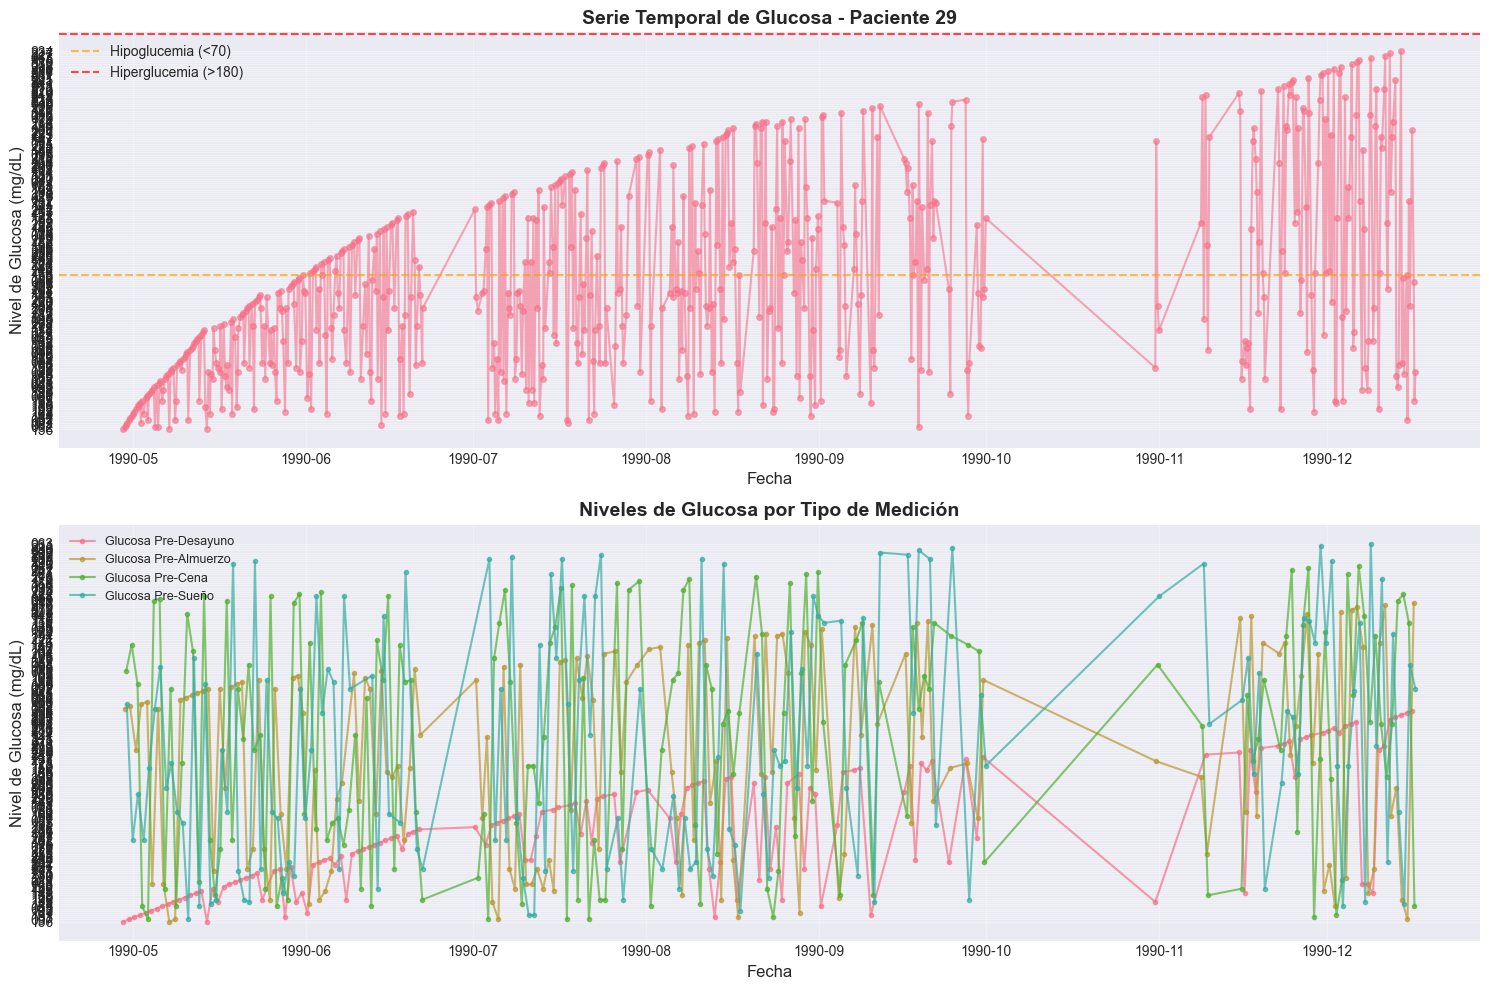


Estadísticas de Glucosa:
count     616
unique    173
top       196
freq       18
Name: value, dtype: object


In [27]:
# Visualizar la serie temporal completa
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Todos los niveles de glucosa
axes[0].plot(df_patient['datetime'], df_patient['value'], 'o-', alpha=0.6, markersize=4)
axes[0].set_title(f'Serie Temporal de Glucosa - Paciente {selected_patient}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha', fontsize=12)
axes[0].set_ylabel('Nivel de Glucosa (mg/dL)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=70, color='orange', linestyle='--', label='Hipoglucemia (<70)', alpha=0.7)
axes[0].axhline(y=180, color='red', linestyle='--', label='Hiperglucemia (>180)', alpha=0.7)
axes[0].legend()

# Gráfico 2: Por tipo de medición
for mtype in df_patient['measurement_type'].unique():
    data = df_patient[df_patient['measurement_type'] == mtype]
    axes[1].plot(data['datetime'], data['value'], 'o-', label=mtype, alpha=0.7, markersize=3)

axes[1].set_title('Niveles de Glucosa por Tipo de Medición', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Nivel de Glucosa (mg/dL)', fontsize=12)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas de Glucosa:")
print(df_patient['value'].describe())

## 5. Agregación Diaria para Análisis de Series Temporales

Para aplicar modelos de series temporales con statsmodels, necesitamos una serie regular (sin gaps). Vamos a agregar los datos por día.

In [28]:
# Crear serie temporal diaria
df_patient['date_only'] = df_patient['datetime'].dt.date

# Convertir value a numérico
df_patient['value'] = pd.to_numeric(df_patient['value'], errors='coerce')

# Agregación diaria - promedio de glucosa
ts_daily = df_patient.groupby('date_only')['value'].agg(['mean', 'std', 'count']).reset_index()
ts_daily.columns = ['date', 'glucose_mean', 'glucose_std', 'measurements']
ts_daily['date'] = pd.to_datetime(ts_daily['date'])
ts_daily = ts_daily.set_index('date')

# Rellenar días faltantes con interpolación
ts_daily = ts_daily.asfreq('D')
ts_daily['glucose_mean'] = ts_daily['glucose_mean'].interpolate(method='linear')

print(f"Serie temporal diaria creada")
print(f"Días totales: {len(ts_daily)}")
print(f"Días con mediciones: {ts_daily['measurements'].notna().sum()}")
print(f"\nPrimeros días:")
ts_daily.head(10)

Serie temporal diaria creada
Días totales: 232
Días con mediciones: 159

Primeros días:


,glucose_mean,glucose_std,measurements
date,,,
1990-04-29,95.25,31.700421,4.0
1990-04-30,133.75,27.427176,4.0
1990-05-01,173.50,23.558438,4.0
1990-05-02,137.50,26.134269,4.0
1990-05-03,120.00,46.740418,4.0
1990-05-04,125.50,57.146012,4.0
1990-05-05,60.25,25.024988,4.0
1990-05-06,151.00,14.023789,4.0
1990-05-07,124.75,22.677081,4.0


## 6. Descomposición de Series Temporales con Statsmodels

La descomposición nos permite identificar:
- **Tendencia**: Movimiento a largo plazo
- **Estacionalidad**: Patrones repetitivos
- **Residuos**: Componente aleatorio

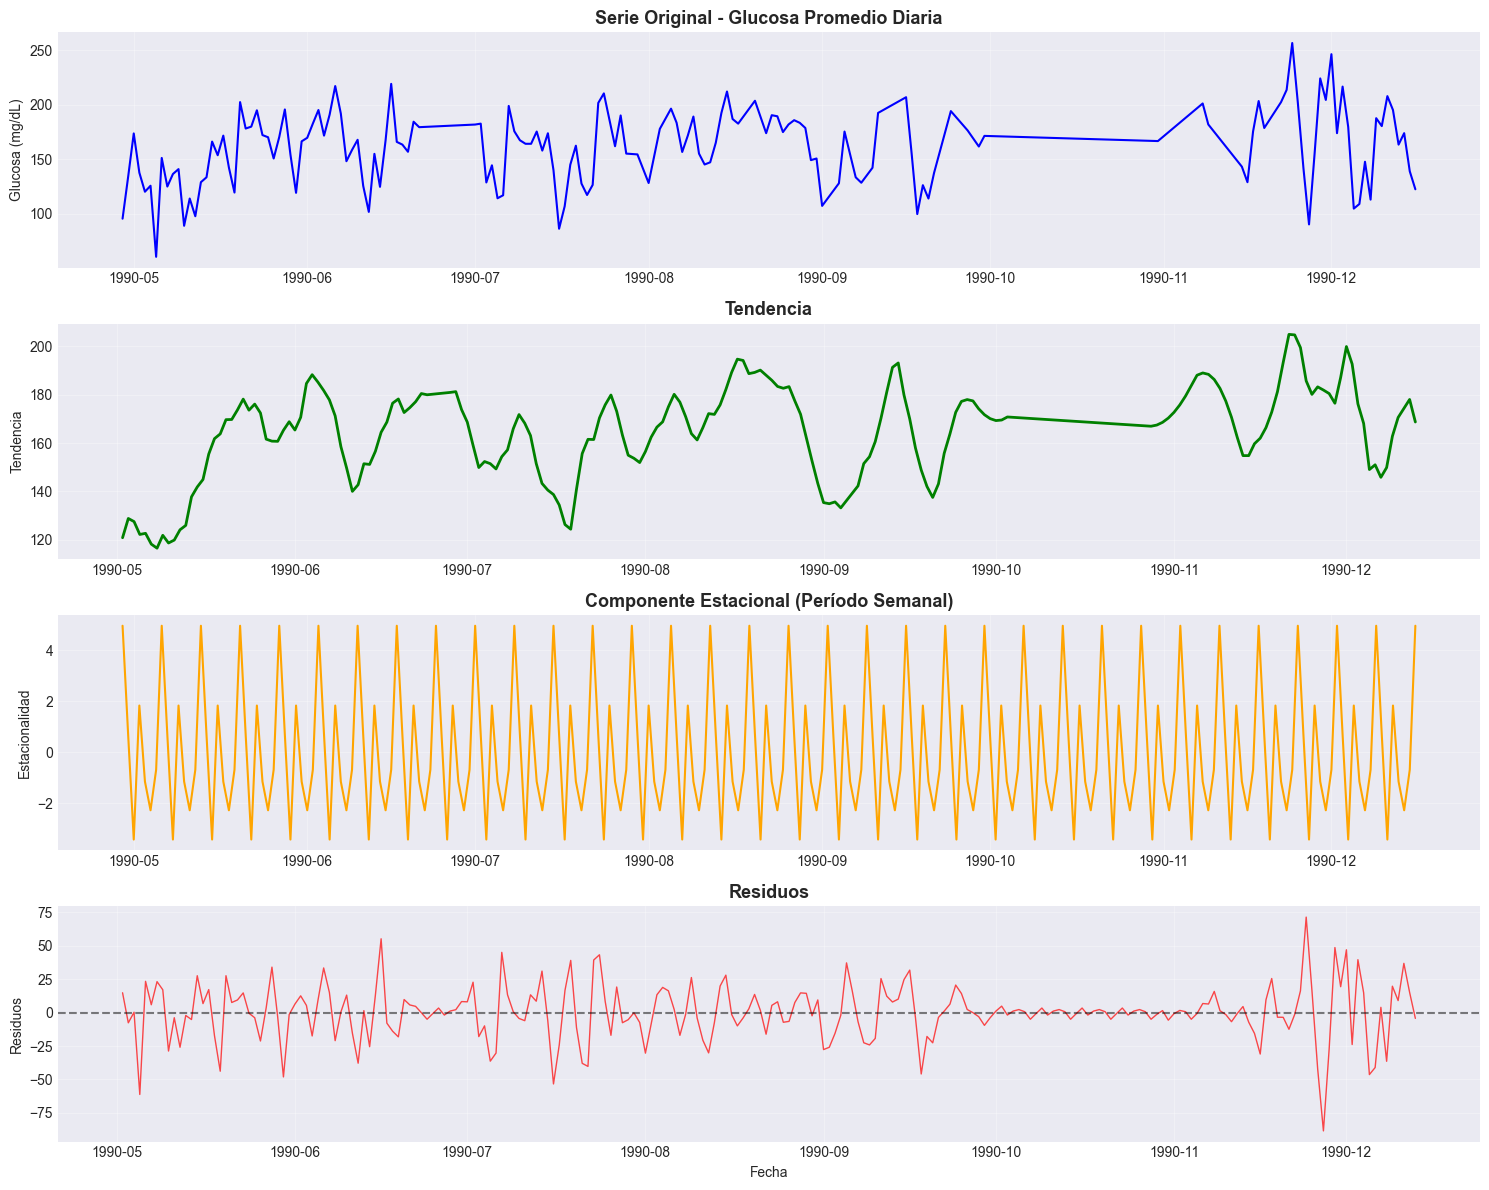

Descomposición completada


In [29]:
# Descomposición de la serie temporal
# Usamos período de 7 días (semanal) para capturar patrones semanales
decomposition = seasonal_decompose(
    ts_daily['glucose_mean'].dropna(),
    model='additive',
    period=7
)

# Visualizar componentes
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Serie original
axes[0].plot(ts_daily.index, ts_daily['glucose_mean'], color='blue', linewidth=1.5)
axes[0].set_title('Serie Original - Glucosa Promedio Diaria', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].grid(True, alpha=0.3)

# Tendencia
axes[1].plot(decomposition.trend, color='green', linewidth=2)
axes[1].set_title('Tendencia', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

# Estacionalidad
axes[2].plot(decomposition.seasonal, color='orange', linewidth=1.5)
axes[2].set_title('Componente Estacional (Período Semanal)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

# Residuos
axes[3].plot(decomposition.resid, color='red', linewidth=1, alpha=0.7)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Residuos', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Residuos')
axes[3].set_xlabel('Fecha')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Descomposición completada")

## 7. Test de Estacionariedad (Augmented Dickey-Fuller)

Una serie es **estacionaria** si sus propiedades estadísticas (media, varianza) no cambian con el tiempo. Esto es importante para muchos modelos de series temporales.

In [30]:
# Test de Dickey-Fuller
def adf_test(series, name=''):
    """Realiza test de Augmented Dickey-Fuller para estacionariedad"""
    result = adfuller(series.dropna(), autolag='AIC')

    print(f'\nTest ADF para {name}:')
    print('='*60)
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Lags utilizados: {result[2]}')
    print(f'Observaciones: {result[3]}')
    print('\nValores críticos:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    # Interpretación
    if result[1] <= 0.05:
        print(f'\nLa serie ES ESTACIONARIA (p-value <= 0.05)')
    else:
        print(f'\nLa serie NO ES ESTACIONARIA (p-value > 0.05)')
    print('='*60)

    return result

# Test sobre la serie original
adf_result = adf_test(ts_daily['glucose_mean'], 'Glucosa Diaria Original')


Test ADF para Glucosa Diaria Original:
ADF Statistic: -6.715310
p-value: 0.000000
Lags utilizados: 3
Observaciones: 228

Valores críticos:
	1%: -3.459
	5%: -2.874
	10%: -2.574

La serie ES ESTACIONARIA (p-value <= 0.05)


## 9. Análisis de Temporalidad: Glucosa Post-Almuerzo (Todos los Pacientes)

Análisis específico de la glucosa post-almuerzo (código 61) agregando datos de todos los pacientes para identificar patrones temporales generales.

In [32]:
# Filtrar solo glucosa post-almuerzo (código 61)
df_post_lunch = df_all[df_all['code'] == 61].copy()

# Convertir valores a numérico
df_post_lunch['value'] = pd.to_numeric(df_post_lunch['value'], errors='coerce')

# Eliminar valores nulos
df_post_lunch = df_post_lunch.dropna(subset=['value'])

print(f"Análisis de Glucosa Post-Almuerzo")
print(f"Total de mediciones: {len(df_post_lunch):,}")
print(f"Pacientes con mediciones: {df_post_lunch['patient_id'].nunique()}")
print(f"Rango de fechas: {df_post_lunch['datetime'].min()} a {df_post_lunch['datetime'].max()}")
print(f"\nEstadísticas descriptivas:")
print(df_post_lunch['value'].describe())

Análisis de Glucosa Post-Almuerzo
Total de mediciones: 22
Pacientes con mediciones: 8
Rango de fechas: 1990-05-01 16:31:00 a 1990-09-29 12:53:00

Estadísticas descriptivas:
count     22.000000
mean     188.363636
std       54.758818
min       72.000000
25%      154.750000
50%      184.000000
75%      222.250000
max      306.000000
Name: value, dtype: float64


In [34]:
# Preparar serie temporal ordenada cronológicamente
df_post_lunch_sorted = df_post_lunch.sort_values('datetime').copy()
df_post_lunch_sorted.set_index('datetime', inplace=True)

print('Serie temporal de glucosa post-almuerzo preparada')
print(f'Total de mediciones: {len(df_post_lunch_sorted)}')
print('\nPrimeras mediciones:')
print(df_post_lunch_sorted[['value', 'patient_id']].head(10))

Serie temporal de glucosa post-almuerzo preparada
Total de mediciones: 22

Primeras mediciones:
                     value patient_id
datetime                             
1990-05-01 16:31:00    230         09
1990-05-02 16:27:00    246         09
1990-05-03 16:33:00    121         09
1990-05-04 16:16:00    306         09
1990-05-06 12:53:00    136         09
1990-05-11 13:07:00    139         09
1990-07-16 13:33:00    208         11
1990-07-22 11:39:00    151         03
1990-07-24 10:47:00    178         03
1990-07-26 11:48:00    192         03


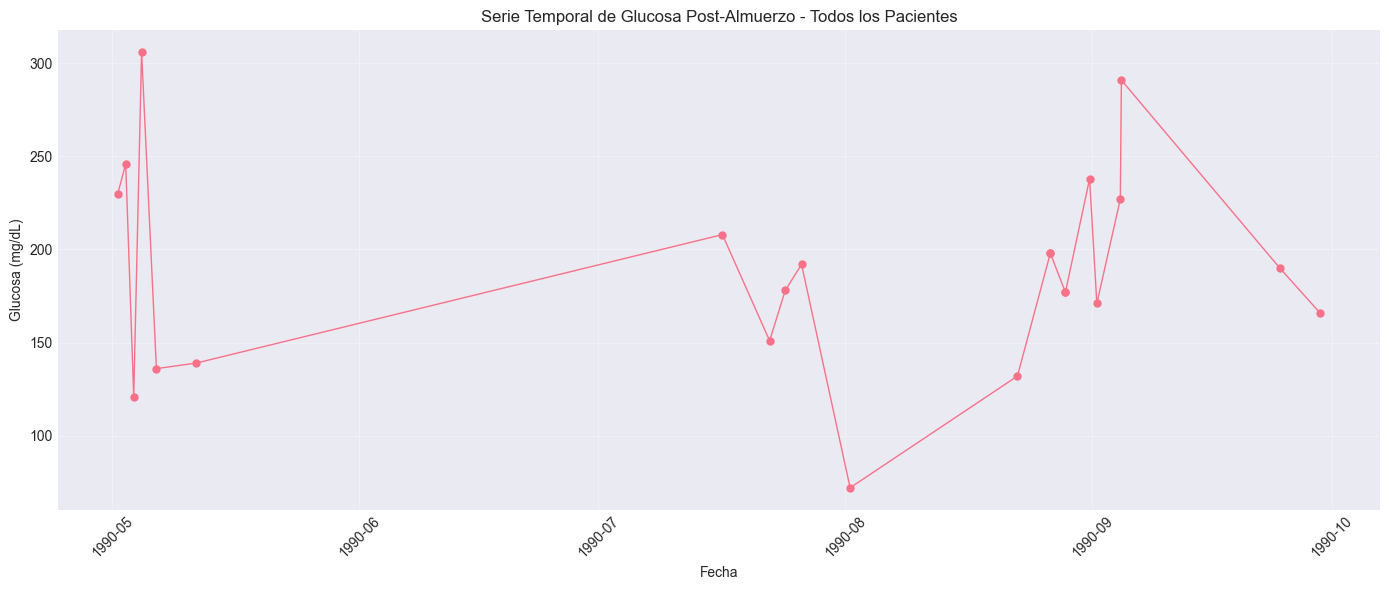

Rango de valores: 72.0 - 306.0 mg/dL
Promedio: 188.4 mg/dL


In [35]:
# Visualización de la serie temporal de glucosa post-almuerzo
plt.figure(figsize=(14, 6))
plt.plot(df_post_lunch_sorted.index, df_post_lunch_sorted['value'], marker='o', linestyle='-', linewidth=1, markersize=5)
plt.title('Serie Temporal de Glucosa Post-Almuerzo - Todos los Pacientes')
plt.xlabel('Fecha')
plt.ylabel('Glucosa (mg/dL)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Rango de valores: {df_post_lunch_sorted["value"].min():.1f} - {df_post_lunch_sorted["value"].max():.1f} mg/dL')
print(f'Promedio: {df_post_lunch_sorted["value"].mean():.1f} mg/dL')

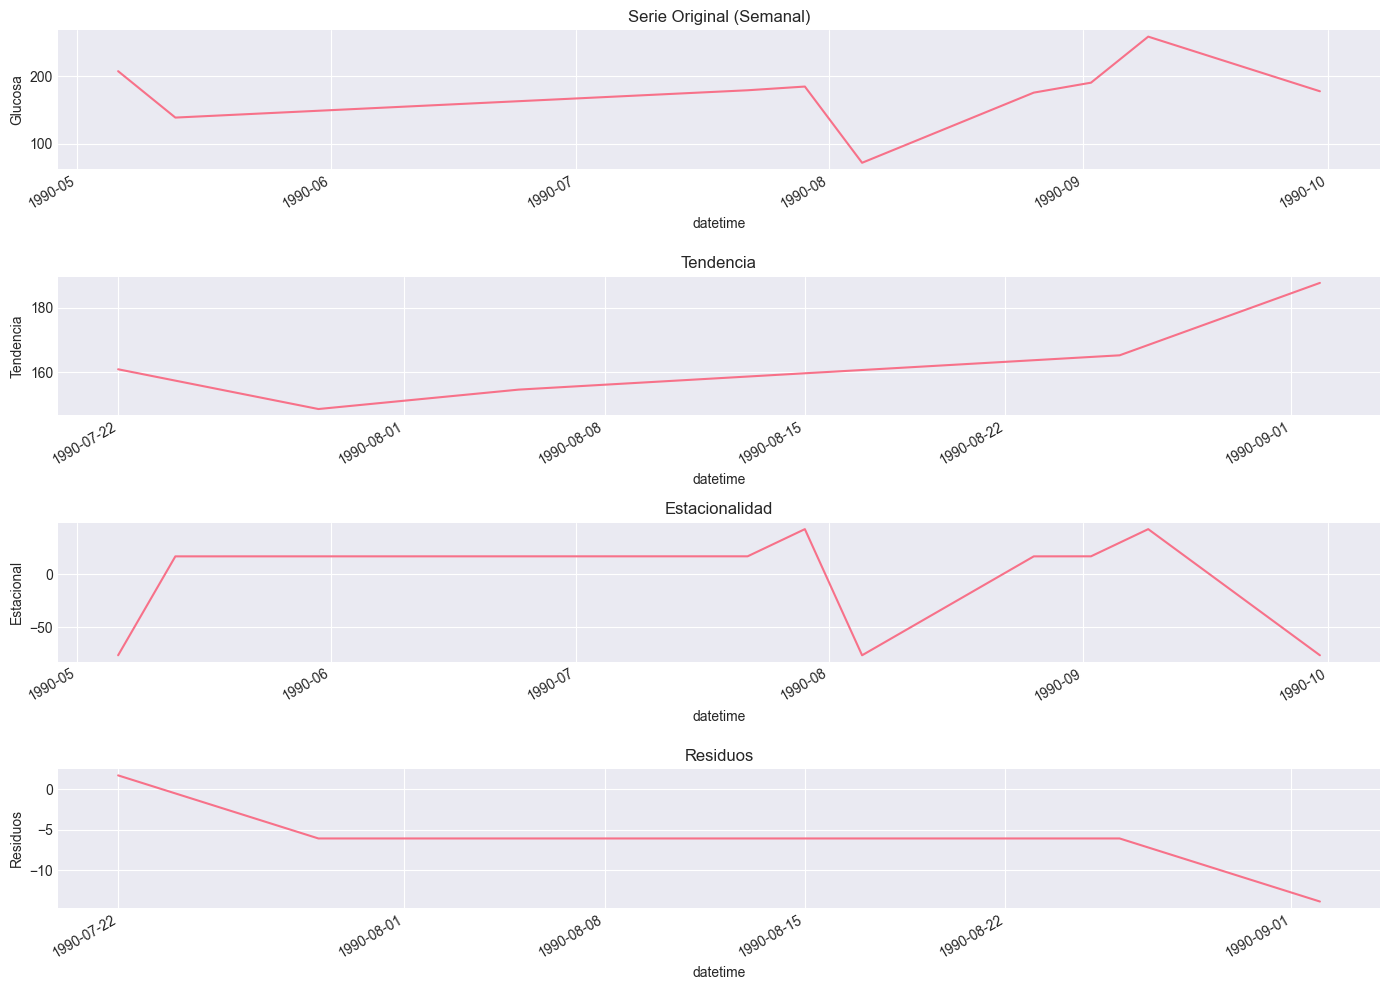

Descomposición estacional completada (frecuencia semanal)


In [ ]:
# Para la descomposición, necesitamos datos más regulares
# Crear serie con frecuencia semanal (promedio por semana)
df_weekly = df_post_lunch_sorted.resample('W')['value'].mean()

# Solo intentar descomposición si tenemos suficientes datos
if len(df_weekly.dropna()) >= 8:  # Al menos 2 meses de datos semanales
    decomposition = seasonal_decompose(df_weekly.dropna(), model='additive', period=4)  # Período mensual

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    decomposition.observed.plot(ax=axes[0], title='Serie Original (Semanal)')
    axes[0].set_ylabel('Glucosa')
    decomposition.trend.plot(ax=axes[1], title='Tendencia')
    axes[1].set_ylabel('Tendencia')
    decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad')
    axes[2].set_ylabel('Estacional')
    decomposition.resid.plot(ax=axes[3], title='Residuos')
    axes[3].set_ylabel('Residuos')
    plt.tight_layout()
    plt.show()

    print('Descomposición estacional completada (frecuencia semanal)')
else:
    print(f'Datos insuficientes para descomposición estacional')
    print(f'Se necesitan al menos 8 semanas con datos, disponibles: {len(df_weekly.dropna())}')

In [37]:
# Test de estacionariedad (ADF) en la serie original
result = adfuller(df_post_lunch_sorted['value'].dropna())

print('Test de Dickey-Fuller Aumentado (ADF)')
print('='*50)
print(f'Estadístico ADF: {result[0]:.4f}')
print(f'p-valor: {result[1]:.4f}')
print(f'Número de lags utilizados: {result[2]}')
print(f'Número de observaciones: {result[3]}')
print('\nValores críticos:')
for key, value in result[4].items():
    print(f'  {key}: {value:.3f}')

if result[1] < 0.05:
    print('\nConclusión: La serie ES estacionaria (p < 0.05)')
else:
    print('\nConclusión: La serie NO es estacionaria (p >= 0.05)')

Test de Dickey-Fuller Aumentado (ADF)
Estadístico ADF: -1.2509
p-valor: 0.6513
Número de lags utilizados: 9
Número de observaciones: 12

Valores críticos:
  1%: -4.138
  5%: -3.155
  10%: -2.714

Conclusión: La serie NO es estacionaria (p >= 0.05)


Análisis de patrones temporales

Estadísticas por paciente:
            count        mean        std  min  max
patient_id                                        
03              5  179.200000  18.157643  151  198
04              2  187.500000  14.849242  177  198
05              1  166.000000        NaN  166  166
08              5  192.000000  88.235480   72  291
09              6  196.333333  75.138982  121  306
11              1  208.000000        NaN  208  208
12              1  171.000000        NaN  171  171
19              1  190.000000        NaN  190  190


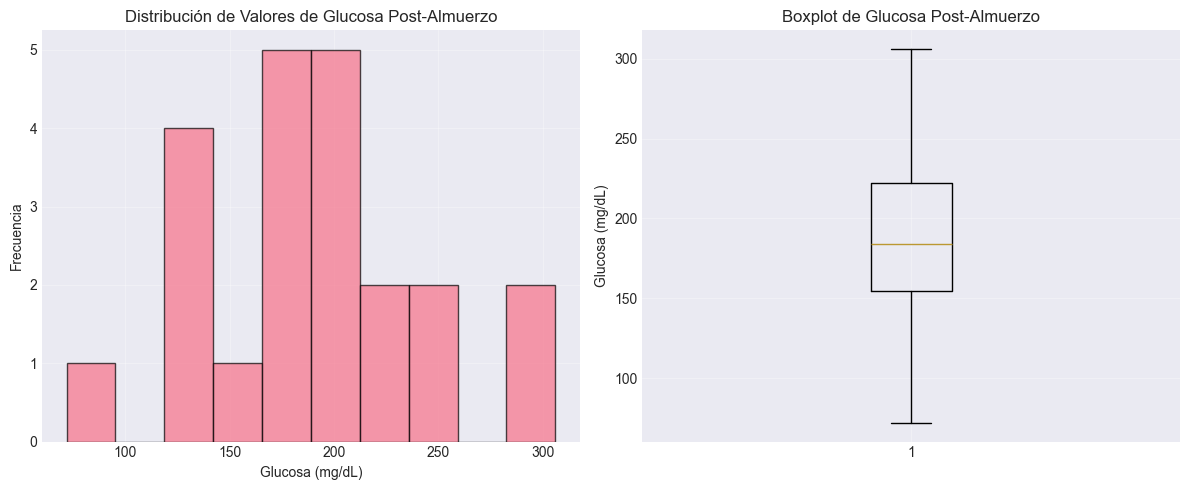


Rango normal de glucosa post-almuerzo en personas sin diabetes: < 140 mg/dL
Mediciones por encima de lo normal (picos diabéticos): 17/22 (77.3%)


In [39]:
# Análisis de patrones temporales adicionales
print('Análisis de patrones temporales')
print('='*50)

# Distribución por paciente
paciente_stats = df_post_lunch.groupby('patient_id')['value'].agg(['count', 'mean', 'std', 'min', 'max'])
print('\nEstadísticas por paciente:')
print(paciente_stats)

# Gráfico de distribución de valores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_post_lunch_sorted['value'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribución de Valores de Glucosa Post-Almuerzo')
plt.xlabel('Glucosa (mg/dL)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df_post_lunch_sorted['value'])
plt.title('Boxplot de Glucosa Post-Almuerzo')
plt.ylabel('Glucosa (mg/dL)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nRango normal de glucosa post-almuerzo en personas sin diabetes: < 140 mg/dL')
above_normal = (df_post_lunch_sorted['value'] > 140).sum()
print(f'Mediciones por encima de lo normal (picos diabéticos): {above_normal}/{len(df_post_lunch_sorted)} ({100*above_normal/len(df_post_lunch_sorted):.1f}%)')

## Identificacion de los 4 Componentes de la Serie Temporal

In [40]:
# Componentes de la Serie Temporal de Glucosa Post-Almuerzo
print('='*70)
print('COMPONENTES DE LA SERIE TEMPORAL')
print('='*70)

# 1. TENDENCIA
print('\n1. TENDENCIA (T)')
print('-'*70)
print('Direccion general de la serie a largo plazo')
print(f'Valor inicial (primera semana): {df_weekly.iloc[0]:.2f} mg/dL')
print(f'Valor final (ultima semana): {df_weekly.iloc[-1]:.2f} mg/dL')
print(f'Cambio total: {df_weekly.iloc[-1] - df_weekly.iloc[0]:.2f} mg/dL')
print(f'Pendiente promedio: {(df_weekly.iloc[-1] - df_weekly.iloc[0])/len(df_weekly):.2f} mg/dL por semana')

# 2. ESTACIONALIDAD
print('\n2. ESTACIONALIDAD (S)')
print('-'*70)
print('Patrones que se repiten en periodos regulares')
print(f'Periodo de estacionalidad detectado: 4 semanas (mensual)')
print(f'Amplitud estacional maxima: {decomposition.seasonal.max():.2f} mg/dL')
print(f'Amplitud estacional minima: {decomposition.seasonal.min():.2f} mg/dL')
print(f'Rango estacional: {decomposition.seasonal.max() - decomposition.seasonal.min():.2f} mg/dL')

# 3. CICLOS
print('\n3. CICLOS (C)')
print('-'*70)
print('Fluctuaciones irregulares de largo plazo sin periodo fijo')
print(f'Duracion del periodo analizado: {len(df_weekly)} semanas')
print(f'Numero de observaciones diarias: {len(df_post_lunch_sorted)}')
print(f'Desviacion estandar de la serie: {df_post_lunch_sorted["value"].std():.2f} mg/dL')
print(f'Coeficiente de variacion: {(df_post_lunch_sorted["value"].std()/df_post_lunch_sorted["value"].mean())*100:.2f}%')

# 4. RUIDO/COMPONENTE IRREGULAR
print('\n4. RUIDO o COMPONENTE IRREGULAR (I)')
print('-'*70)
print('Variaciones aleatorias que no siguen ningun patron')
print(f'Media de los residuos: {decomposition.resid.mean():.2f} mg/dL')
print(f'Desviacion estandar de residuos: {decomposition.resid.std():.2f} mg/dL')
print(f'Residuo maximo: {decomposition.resid.max():.2f} mg/dL')
print(f'Residuo minimo: {decomposition.resid.min():.2f} mg/dL')

print('\n' + '='*70)
print('Modelo Aditivo: Y(t) = T(t) + S(t) + C(t) + I(t)')
print('='*70)

COMPONENTES DE LA SERIE TEMPORAL

1. TENDENCIA (T)
----------------------------------------------------------------------
Direccion general de la serie a largo plazo
Valor inicial (primera semana): 207.80 mg/dL
Valor final (ultima semana): 178.00 mg/dL
Cambio total: -29.80 mg/dL
Pendiente promedio: -1.35 mg/dL por semana

2. ESTACIONALIDAD (S)
----------------------------------------------------------------------
Patrones que se repiten en periodos regulares
Periodo de estacionalidad detectado: 4 semanas (mensual)
Amplitud estacional maxima: 42.59 mg/dL
Amplitud estacional minima: -76.44 mg/dL
Rango estacional: 119.03 mg/dL

3. CICLOS (C)
----------------------------------------------------------------------
Fluctuaciones irregulares de largo plazo sin periodo fijo
Duracion del periodo analizado: 22 semanas
Numero de observaciones diarias: 22
Desviacion estandar de la serie: 54.76 mg/dL
Coeficiente de variacion: 29.07%

4. RUIDO o COMPONENTE IRREGULAR (I)
------------------------------

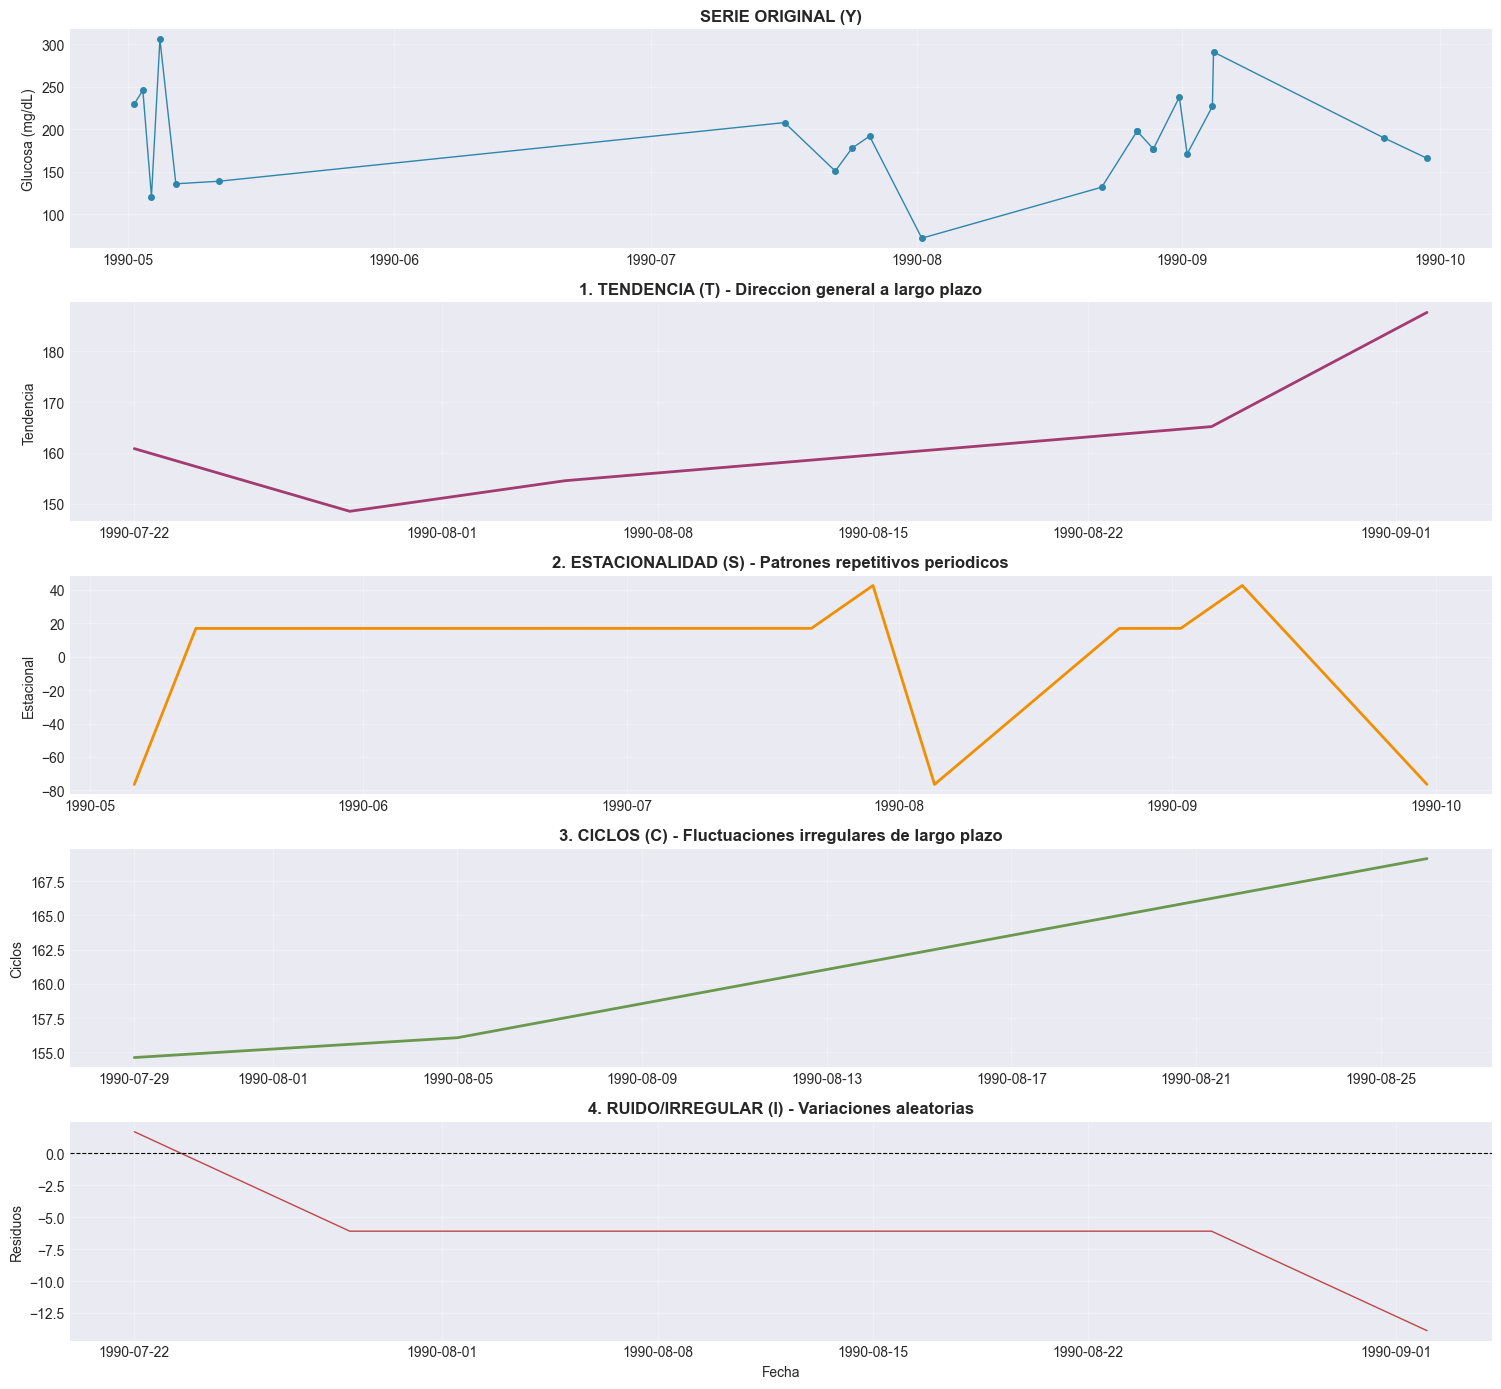

In [41]:
# Visualizacion conjunta de los 4 componentes
fig, axes = plt.subplots(5, 1, figsize=(15, 14))

# Serie Original
axes[0].plot(df_post_lunch_sorted.index, df_post_lunch_sorted['value'], 'o-', linewidth=1, markersize=4, color='#2E86AB')
axes[0].set_title('SERIE ORIGINAL (Y)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].grid(True, alpha=0.3)

# Tendencia
axes[1].plot(decomposition.trend.index, decomposition.trend, linewidth=2, color='#A23B72')
axes[1].set_title('1. TENDENCIA (T) - Direccion general a largo plazo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

# Estacionalidad
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, linewidth=2, color='#F18F01')
axes[2].set_title('2. ESTACIONALIDAD (S) - Patrones repetitivos periodicos', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Estacional')
axes[2].grid(True, alpha=0.3)

# Ciclos (representado por la tendencia suavizada)
trend_smooth = decomposition.trend.rolling(window=3, center=True).mean()
axes[3].plot(trend_smooth.index, trend_smooth, linewidth=2, color='#6A994E')
axes[3].set_title('3. CICLOS (C) - Fluctuaciones irregulares de largo plazo', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Ciclos')
axes[3].grid(True, alpha=0.3)

# Ruido/Residuos
axes[4].plot(decomposition.resid.index, decomposition.resid, linewidth=1, color='#BC4749')
axes[4].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[4].set_title('4. RUIDO/IRREGULAR (I) - Variaciones aleatorias', fontsize=12, fontweight='bold')
axes[4].set_ylabel('Residuos')
axes[4].set_xlabel('Fecha')
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Tabla resumen de caracteristicas de cada componente
import pandas as pd

componentes_data = {
    'Componente': ['Tendencia (T)', 'Estacionalidad (S)', 'Ciclos (C)', 'Ruido (I)'],
    'Descripcion': [
        'Direccion general creciente, decreciente o estable',
        'Patrones que se repiten en periodos fijos',
        'Fluctuaciones irregulares sin periodo exacto',
        'Variaciones aleatorias impredecibles'
    ],
    'Valor Medio': [
        f'{decomposition.trend.mean():.2f}',
        f'{decomposition.seasonal.mean():.2f}',
        f'{trend_smooth.mean():.2f}',
        f'{decomposition.resid.mean():.2f}'
    ],
    'Desv. Estandar': [
        f'{decomposition.trend.std():.2f}',
        f'{decomposition.seasonal.std():.2f}',
        f'{trend_smooth.std():.2f}',
        f'{decomposition.resid.std():.2f}'
    ],
    'Rango': [
        f'{decomposition.trend.max() - decomposition.trend.min():.2f}',
        f'{decomposition.seasonal.max() - decomposition.seasonal.min():.2f}',
        f'{trend_smooth.max() - trend_smooth.min():.2f}',
        f'{decomposition.resid.max() - decomposition.resid.min():.2f}'
    ]
}

df_componentes = pd.DataFrame(componentes_data)
print('\nRESUMEN DE LOS 4 COMPONENTES DE LA SERIE TEMPORAL')
print('='*100)
print(df_componentes.to_string(index=False))
print('='*100)


RESUMEN DE LOS 4 COMPONENTES DE LA SERIE TEMPORAL
        Componente                                        Descripcion Valor Medio Desv. Estandar  Rango
     Tendencia (T) Direccion general creciente, decreciente o estable      163.35          15.00  39.19
Estacionalidad (S)          Patrones que se repiten en periodos fijos       -8.49          52.03 119.03
        Ciclos (C)       Fluctuaciones irregulares sin periodo exacto      159.95           7.99  14.51
         Ruido (I)               Variaciones aleatorias impredecibles       -6.09           5.51  15.59
